# 1.  1. Import dan Eksplorasi Awal Dataset

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('olist_order_reviews_dataset.csv')

# Ukuran dataset
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

# Tampilkan 5 data teratas
display(df.head())

# Informasi umum
df.info()

# Statistik deskriptif
display(df.describe(include='all'))

# Cek tipe data unik per kolom
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Jumlah baris: 100000, Jumlah kolom: 7


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   review_id                100000 non-null  object
 1   order_id                 100000 non-null  object
 2   review_score             100000 non-null  int64 
 3   review_comment_title     11715 non-null   object
 4   review_comment_message   41753 non-null   object
 5   review_creation_date     100000 non-null  object
 6   review_answer_timestamp  100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,100000,100000,100000.000000,11715,41753,100000,100000
unique,99173,99441,NaN,4600,36921,637,99010
top,0c76e7a547a531e7bf9f0b99cba071c1,df56136b8031ecd28e200bb18e6ddb2e,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,426,230,466,4
mean,NaN,NaN,4.070890,NaN,NaN,NaN,NaN
std,NaN,NaN,1.359663,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


review_id: 99173 unique values
order_id: 99441 unique values
review_score: 5 unique values
review_comment_title: 4600 unique values
review_comment_message: 36921 unique values
review_creation_date: 637 unique values
review_answer_timestamp: 99010 unique values


# 2. Missing Values — Deteksi & Penanganan

In [17]:
# Total missing value
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_percent})
display(missing_df[missing_df['Missing Values'] > 0])

# Penanganan:
# Misalnya, 'review_comment_title' dan 'review_comment_message' banyak null karena user tidak menulis komentar
df['review_comment_title'] = df['review_comment_title'].fillna('No Title')
df['review_comment_message'] = df['review_comment_message'].fillna('No Message')


,Missing Values,Percentage (%)
review_comment_title,88285,88.285
review_comment_message,58247,58.247


# 3. Outliers — Deteksi dan Penanganan

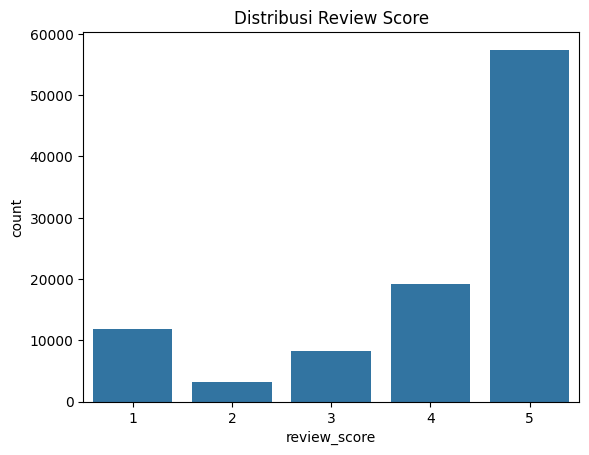

Jumlah outlier response time: 4959


In [18]:
# Visualisasi distribusi skor
sns.countplot(x='review_score', data=df)
plt.title("Distribusi Review Score")
plt.show()

# Cek outlier pada kolom review_creation_date (durasi review yang terlalu lama?)
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'])

# Durasi waktu tanggapan review
df['review_response_time'] = (df['review_answer_timestamp'] - df['review_creation_date']).dt.days

# Deteksi outlier response time
q1 = df['review_response_time'].quantile(0.25)
q3 = df['review_response_time'].quantile(0.75)
iqr = q3 - q1

outlier_mask = (df['review_response_time'] < q1 - 1.5*iqr) | (df['review_response_time'] > q3 + 1.5*iqr)
print(f"Jumlah outlier response time: {outlier_mask.sum()}")

# Opsional: Buang outlier
df = df[~outlier_mask]


# 4. Noise — Contoh Pembersihan Teks

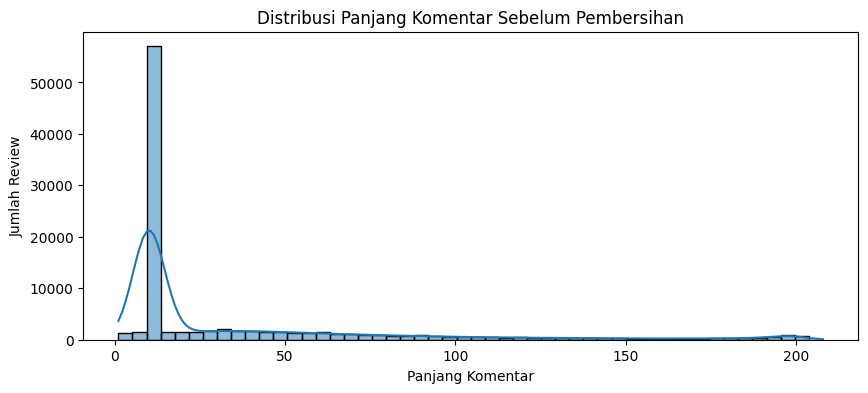

Contoh komentar noise:


,review_comment_message
55,boa
160,OK
299,A
465,10
676,Sdds
746,show
777,bom
815,N/a
944,*******************
1032,Bom


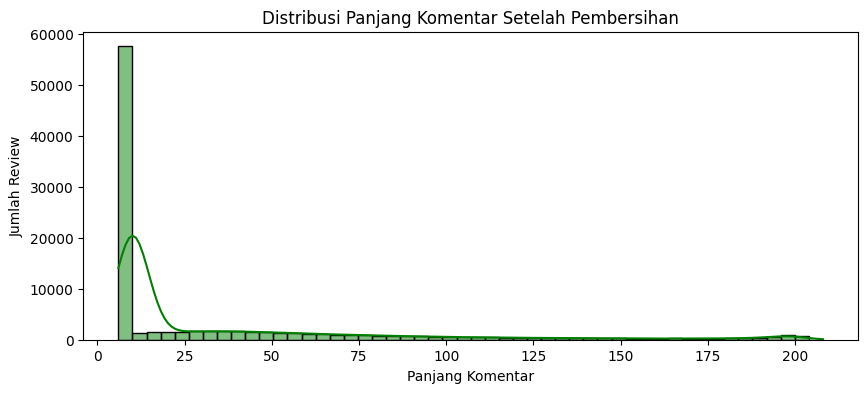

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Kolom panjang komentar (awal)
df['comment_length'] = df['review_comment_message'].apply(lambda x: len(str(x)))

# Visualisasi distribusi panjang komentar sebelum dibersihkan
plt.figure(figsize=(10,4))
sns.histplot(df['comment_length'], bins=50, kde=True)
plt.title("Distribusi Panjang Komentar Sebelum Pembersihan")
plt.xlabel("Panjang Komentar")
plt.ylabel("Jumlah Review")
plt.show()

# Fungsi deteksi komentar noise
def is_noisy(text):
    text = str(text).strip().lower()
    if len(text) <= 3:
        return True
    if re.fullmatch(r'(.)\1{2,}', text):  # huruf sama berulang
        return True
    if re.fullmatch(r'[^a-zA-Z0-9]+', text):  # hanya tanda baca
        return True
    if len(text.split()) == 1 and len(text) <= 4:
        return True
    return False

# Tandai komentar noise
df['noisy_flag'] = df['review_comment_message'].apply(is_noisy)

# Contoh komentar noise
print("Contoh komentar noise:")
display(df[df['noisy_flag']][['review_comment_message']].head(10))

# Hapus komentar noise
df = df[~df['noisy_flag']]
df.drop(columns=['noisy_flag'], inplace=True)

# Setelah itu filter komentar terlalu pendek (panjang <= 5)
df = df[df['review_comment_message'].apply(lambda x: len(str(x))) > 5]

# Hitung ulang panjang komentar setelah bersih
df['comment_length'] = df['review_comment_message'].apply(lambda x: len(str(x)))

# Visualisasi ulang setelah dibersihkan
plt.figure(figsize=(10,4))
sns.histplot(df['comment_length'], bins=50, kde=True, color='green')
plt.title("Distribusi Panjang Komentar Setelah Pembersihan")
plt.xlabel("Panjang Komentar")
plt.ylabel("Jumlah Review")
plt.show()


# 5. Duplikasi — Deteksi dan Penanganan

In [20]:
# Cek apakah ada duplikasi berdasarkan review_id
print(f"Jumlah duplikasi berdasarkan review_id: {df.duplicated('review_id').sum()}")

# Hapus duplikat
df = df.drop_duplicates(subset='review_id')


Jumlah duplikasi berdasarkan review_id: 779


# 6. Integrasi dan Penanganan Inkonsistensi

In [21]:
# Simulasi data tambahan
orders = pd.DataFrame({
    'order_id': df['order_id'].sample(1000).values,
    'customer_city': np.random.choice(['Sao Paulo', 'São Paulo', 'sao paulo', 'Rio de Janeiro'], size=1000),
    'order_purchase_timestamp': pd.date_range(start='2022-01-01', periods=1000, freq='h')
})

# Merge dengan df
merged_df = pd.merge(df, orders, on='order_id', how='inner')

# Sebelum dibersihkan: lihat variasi kota
print("Variasi nama kota sebelum dibersihkan:")
display(merged_df['customer_city'].value_counts())

# Koreksi inkonsistensi format nama kota
merged_df['customer_city_clean'] = (
    merged_df['customer_city']
    .str.lower()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Format tanggal seragam
merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])

# Setelah dibersihkan: lihat variasi nama kota
print("\nVariasi nama kota setelah dibersihkan:")
display(merged_df['customer_city_clean'].value_counts())

# Tampilkan 5 data gabungan
print("\nContoh data hasil penggabungan:")
display(merged_df[['order_id', 'customer_city', 'customer_city_clean', 'order_purchase_timestamp']].head())


Variasi nama kota sebelum dibersihkan:


customer_city
São Paulo         259
Sao Paulo         253
Rio de Janeiro    252
sao paulo         245
Name: count, dtype: int64


Variasi nama kota setelah dibersihkan:


customer_city_clean
sao paulo         757
rio de janeiro    252
Name: count, dtype: int64


Contoh data hasil penggabungan:


,order_id,customer_city,customer_city_clean,order_purchase_timestamp
0,f3a9c397a2fa5a2366b4b96bc15737f6,Rio de Janeiro,rio de janeiro,2022-02-02 00:00:00
1,bb4648eb654b7296660ddcbc2ac64c0f,São Paulo,sao paulo,2022-01-02 17:00:00
2,15c8f741c0b7deafafea8af0f7bb6852,sao paulo,sao paulo,2022-01-26 03:00:00
3,7bdfa70c4049e7319a3182997e27cb95,sao paulo,sao paulo,2022-01-03 14:00:00
4,ab07b6c48672e9876b9f11c746d98d3e,Rio de Janeiro,rio de janeiro,2022-02-02 17:00:00
